# **Lab 03.2 - Introduction to Deep Q-Network**

##### Copyright by UIT-NC@NT549

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>

This lab consists of 3 parts:
<ol style="margin-left: 20px;">
  <li><strong>Part 1: DQN on VacuumCleanerEnv</strong> - Custom environment with grid world and visual feedback</li>
  <li><strong>Part 2: DQN on LoadBalancingEnv</strong> - Multi-server task distribution problem</li>
  <li><strong>Part 3: Stable-Baselines3 DQN</strong> - Using production-ready RL library for faster implementation</li>
</ol>
</div>

### Imports and Setup

In [1]:
# ============================================================================
# Imports and runtime stability config
# ============================================================================

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random

# Reduce thread contention in notebook kernels (more stable on shared/limited CPUs).
# Guard set_num_interop_threads so this block is re-runnable in an existing kernel.
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    # Safe to ignore when interop threads were already configured earlier in this session.
    pass

# Fixed seeds => easier to compare student results across runs
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Use GPU if available; otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Quick diagnostic print so students can verify runtime environment
print(f"\n{'='*60}")
print(f"Device: {device}")
print(f"PyTorch Version: {torch.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"Gymnasium Version: {gym.__version__}")
print(f"Torch Threads: {torch.get_num_threads()}")
print(f"{'='*60}\n")


Device: cpu
PyTorch Version: 2.10.0+cpu
NumPy Version: 2.4.2
Gymnasium Version: 1.2.3
Torch Threads: 1



---

# Shared Components for DQN

The following classes (ReplayBuffer, DQNNetwork, DQNAgent) are reused across all parts of this lab. They are modular and can be adapted for different environments.

### Shared Component 1: Replay Buffer

In [2]:
# ============================================================================
# Shared component: replay buffer
# ============================================================================
# Why this matters:
#+ DQN learns better from randomly sampled past experiences than from strictly
#+ consecutive transitions (which are highly correlated).

class ReplayBuffer:
    """Store and sample experiences for DQN training.

    A transition has shape: (state, action, reward, next_state, done)
    """

    def __init__(self, capacity=10000):
        """Create bounded memory for transitions.

        Args:
            capacity: Maximum transitions kept in memory.
        """
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        """Append one transition into replay memory."""
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        """Randomly sample a mini-batch and convert to tensors on target device.

        Returns:
            states, actions, rewards, next_states, dones
        """
        # Instruction:
        # 1) Use random.sample to get a batch of transitions from self.buffer
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        batch = random.sample(self.buffer, batch_size)

        # Instruction:
        # 1) Convert each component (state/action/reward/next_state/done) to NumPy arrays.
        # 2) Convert arrays to torch tensors on `device`.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        states_np = np.array([t[0] for t in batch], dtype=np.float32)
        actions_np = np.array([t[1] for t in batch], dtype=np.int64)
        rewards_np = np.array([t[2] for t in batch], dtype=np.float32)
        next_states_np = np.array([t[3] for t in batch], dtype=np.float32)
        dones_np = np.array([t[4] for t in batch], dtype=np.float32)

        # 3) Convert numpy arrays to PyTorch tensors and move to device
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        states = torch.from_numpy(states_np).to(device)
        actions = torch.from_numpy(actions_np).to(device)
        rewards = torch.from_numpy(rewards_np).to(device)
        next_states = torch.from_numpy(next_states_np).to(device)
        dones = torch.from_numpy(dones_np).to(device)

        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

print("✓ ReplayBuffer class defined")


✓ ReplayBuffer class defined


### Shared Component 2: DQN Network

In [3]:
# ============================================================================
# Shared component: Q-network
# ============================================================================
# This neural network approximates Q(s, a) for all actions a at once.

class DQNNetwork(nn.Module):
    """Simple MLP-based Deep Q-Network."""
    
    def __init__(self, state_size, action_size, hidden_size=128):
        """Initialize network layers.

        Args:
            state_size: Number of features in state vector.
            action_size: Number of discrete actions.
            hidden_size: Width of hidden layer.
        """
        super(DQNNetwork, self).__init__()
        # Instruction:
        # 1) Define a linear layer (self.fc1) that maps state_size to
        #    a hidden layer of size 64
        # 2) Define a ReLU activation (self.relu)
        # 3) Define a linear layer (self.fc2) that maps the hidden layer
        #    to action_size (output Q-values for each action)
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, action_size)
    
    def forward(self, state):
        """Compute Q-values for each possible action given a state batch."""
        x = self.fc1(state)
        x = self.relu(x)
        q_values = self.fc2(x)
        return q_values

print("✓ DQNNetwork class defined")

✓ DQNNetwork class defined


### Shared Component 3: DQN Agent

In [4]:
# ============================================================================
# Shared component: DQN agent
# ============================================================================

class DQNAgent:
    """Reusable Deep Q-Learning agent for discrete-action environments."""

    def __init__(self, state_size, action_size, learning_rate=1e-3, gamma=0.99):
        """Initialize model, optimizer, and replay memory.

        Args:
            state_size: State feature dimension.
            action_size: Number of valid actions.
            learning_rate: Adam learning rate.
            gamma: Reward discount factor.
        """
        self.state_size = state_size
        self.action_size = action_size
        self.gamma = gamma

        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995

        # Instruction:
        # 1) Create q_network and target_network as instances of DQNNetwork.
        # 2) Move networks to device (CPU or GPU).
        # 3) Initialize target_network weights to match q_network and set to eval mode.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        self.q_network = DQNNetwork(state_size, action_size).to(device)
        self.target_network = DQNNetwork(state_size, action_size).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()

        self.optimizer = optim.Adam(self.q_network.parameters(), lr=learning_rate)
        self.loss_fn = nn.MSELoss()

        self.replay_buffer = ReplayBuffer(capacity=10000)
        self.update_counter = 0

    def select_action(self, state, training=True):
        if training and random.random() < self.epsilon:
            return random.randint(0, self.action_size - 1)

        # Instruction:
        # Convert state to tensor shape [1, state_size], run q_network, return argmax action.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        state_array = np.array(state, dtype=np.float32)
        state_tensor = torch.from_numpy(state_array).unsqueeze(0).to(device)

        with torch.no_grad():
            q_values = self.q_network(state_tensor)

        return q_values.argmax(dim=1).item()

    def store_transition(self, state, action, reward, next_state, done):
        state_array = np.array(state, dtype=np.float32)
        next_state_array = np.array(next_state, dtype=np.float32)
        self.replay_buffer.push(state_array, action, reward, next_state_array, done)

    def train_step(self, batch_size=32):
        if len(self.replay_buffer) < batch_size:
            return

        states, actions, rewards, next_states, dones = self.replay_buffer.sample(batch_size)

        # Instruction:
        # Implement one DQN update step.
        # 1) Compute q_values for chosen actions.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # Thu thập Q-values từ mạng chính và chọn ra giá trị ứng với action đã thực hiện
        q_values = self.q_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        # 2) Compute target_q_values using target network.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        with torch.no_grad():
            next_q_values = self.target_network(next_states).max(dim=1)[0]
            # Công thức Bellman: Q_target = r + gamma * max(Q_next) * (1 - done)
            target_q_values = rewards + self.gamma * next_q_values * (1 - dones)

        # 3) Compute MSE loss and optimize.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        self.optimizer.zero_grad()
        loss = self.loss_fn(q_values, target_q_values)
        loss.backward()
        self.optimizer.step()

        # 4) Sync target network every 100 updates.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        self.update_counter += 1
        if self.update_counter % 100 == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())
            # HERE+

    def decay_epsilon(self):
        # Decay epsilon after each episode.
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

print("✓ DQNAgent class defined")


✓ DQNAgent class defined


---

# PART 1: DQN on VacuumCleanerEnv

A custom grid-based environment where the agent must clean a 5x5 grid by visiting all dirty cells.

### 1.1: Define VacuumCleanerEnv

Custom Gymnasium environment for vacuum cleaning task.

In [ ]:
# ============================================================================
# Part 1 environment: VacuumCleanerEnv
# ============================================================================
# Problem setup:
#+ Grid world 5x5. Agent starts at cell 0.
#+ Every other cell is initially dirty.
#+ Goal: move and clean as many cells as possible before max_steps.

class VacuumCleanerEnv(gym.Env):
    """Grid-based vacuum cleaning task with discrete movement actions."""
    
    def __init__(self, grid_size=5):
        """Initialize environment dynamics and spaces."""
        super().__init__()
        self.grid_size = grid_size
        self.num_cells = grid_size * grid_size
        
        # Actions: 0=up, 1=down, 2=left, 3=right
        self.action_space = spaces.Discrete(4)
        
        # Observation = [one-hot position (25)] + [dirty-mask (25)] => length 50
        self.observation_space = spaces.Box(low=0, high=1, shape=(50,), dtype=np.float32)
        
        self.agent_pos = 0
        self.dirty_cells = set(range(1, self.num_cells))
        self.steps = 0
        self.max_steps = 100
        self.total_reward = 0.0
    
    def _get_state(self):
        """Encode current environment state as a float32 vector."""
        state = np.zeros(50, dtype=np.float32)
        
        # Position channel (one-hot)
        state[self.agent_pos] = 1.0
        
        # Dirt channel (binary mask)
        for cell in self.dirty_cells:
            state[25 + cell] = 1.0
        
        return state
    
    def reset(self, seed=None):
        """Reset to initial configuration for a new episode."""
        super().reset(seed=seed)
        self.agent_pos = 0
        self.dirty_cells = set(range(1, self.num_cells))
        self.steps = 0
        self.total_reward = 0.0
        return self._get_state(), {}
    
    def step(self, action):
        """Apply one action and return Gymnasium transition tuple."""
        self.steps += 1
        row, col = divmod(self.agent_pos, self.grid_size)
        
        # Apply bounded movement
        if action == 0:
            row = max(0, row - 1)
        elif action == 1:
            row = min(self.grid_size - 1, row + 1)
        elif action == 2:
            col = max(0, col - 1)
        elif action == 3:
            col = min(self.grid_size - 1, col + 1)
        
        self.agent_pos = row * self.grid_size + col
        
        # Reward design: +10 for cleaning new dirty cell, -0.1 otherwise
        if self.agent_pos in self.dirty_cells:
            self.dirty_cells.remove(self.agent_pos)
            reward = 10.0
        else:
            reward = -0.1
        
        self.total_reward += reward
        
        terminated = len(self.dirty_cells) == 0
        truncated = self.steps >= self.max_steps
        
        return self._get_state(), reward, terminated, truncated, {}
    
    def render(self, mode='human'):
        """Render environment as text grid.

        mode='human': print to notebook output
        mode='ansi' : return string for custom logging/animation
        """
        grid = [['.' for _ in range(self.grid_size)] for _ in range(self.grid_size)]
        
        # Mark dirty cells
        for cell in self.dirty_cells:
            r, c = divmod(cell, self.grid_size)
            grid[r][c] = 'D'
        
        # Mark agent
        r, c = divmod(self.agent_pos, self.grid_size)
        grid[r][c] = 'A'
        
        lines = [' '.join(row) for row in grid]
        cleaned = (self.num_cells - 1) - len(self.dirty_cells)
        clean_ratio = cleaned / (self.num_cells - 1)
        lines.append(f"Steps: {self.steps}/{self.max_steps} | Cleaned: {cleaned}/{self.num_cells - 1} ({clean_ratio:.1%}) | Total reward: {self.total_reward:.2f}")
        text = '\n'.join(lines)
        
        if mode == 'ansi':
            return text
        print(text)
        print()

print("✓ VacuumCleanerEnv class defined")

### 1.2: Training DQN on VacuumCleanerEnv

In [ ]:
# ============================================================================
# Part 1 training loop
# ============================================================================
print("\n" + "="*60)
print("PART 1: DQN ON VACUUMCLEANERENV")
print("="*60)

print("\n1.2: Training on Custom VacuumCleanerEnv")
print("-" * 60)

env1 = VacuumCleanerEnv(grid_size=5)
agent1 = DQNAgent(state_size=50, action_size=4, learning_rate=1e-3)

num_episodes = 250
batch_size = 32

episode_rewards = []
episode_lengths = []

print(f"\nTraining for {num_episodes} episodes...\n")

for episode in range(num_episodes):
    state, _ = env1.reset()
    episode_reward = 0
    step_count = 0
    done = False

    while not done:
        # Instruction:
        # 1) Select action.
        # 2) Step environment.
        # 3) Store transition and train.
        # 4) Update state and counters.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        action = agent1.select_action(state, training=True)
        next_state, reward, terminated, truncated, _ = env1.step(action)
        done = terminated or truncated
        agent1.store_transition(state, action, reward, next_state, done)
        agent1.train_step(batch_size)
        episode_reward += reward
        step_count += 1
        state = next_state

    agent1.decay_epsilon()
    episode_rewards.append(episode_reward)
    episode_lengths.append(step_count)

    if (episode + 1) % 50 == 0:
        avg_reward = np.mean(episode_rewards[-50:])
        print(f"Episode {episode+1:3d}/{num_episodes} | Avg Reward (last 50): {avg_reward:.2f} | Epsilon: {agent1.epsilon:.3f}")

print(f"\nTraining completed!")
print(f"Final average reward (last 50 episodes): {np.mean(episode_rewards[-50:]):.2f}")


### 1.3: Evaluation and Visualization

In [ ]:
# ============================================================================
# Part 1 evaluation
# ============================================================================
# Tier-based evaluation:
# - Basic success: cleaned >= 20%
# - Good success : cleaned >= 50%
# - Full success : cleaned 100%

print("\n1.3: Evaluation on VacuumCleanerEnv")
print("-" * 60)

eval_episodes = 30
eval_rewards = []
eval_clean_ratios = []
eval_full_completed = []

print(f"\nEvaluating on {eval_episodes} episodes (greedy policy)...\n")

for _ in range(eval_episodes):
    state, _ = env1.reset()
    episode_reward = 0.0
    done = False
    terminated = False

    while not done:
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        action = None
        next_state, reward, terminated, truncated, _ = env1.step(action)
        done = terminated or truncated
        episode_reward += reward
        state = next_state

    cleaned = (env1.num_cells - 1) - len(env1.dirty_cells)
    clean_ratio = cleaned / (env1.num_cells - 1)
    eval_rewards.append(episode_reward)
    eval_clean_ratios.append(clean_ratio)
    eval_full_completed.append(bool(terminated))

# Instruction:
# Compute average reward, average clean ratio, and success rates for each tier...
### YOU NEED TO WRITE YOUR CODE BELOW ###
basic_success_rate = None
good_success_rate = None
full_completion_rate = None
avg_clean_ratio = None

print("Evaluation Results:")
print(f"  Average Reward: {np.mean(eval_rewards):.2f}")
print(f"  Average Clean Ratio: {avg_clean_ratio:.1f}%")
print(f"  Basic Success Rate (>=20% cleaned): {basic_success_rate:.1f}%")
print(f"  Good Success Rate (>=50% cleaned): {good_success_rate:.1f}%")
print(f"  Full Completion Rate (100% cleaned): {full_completion_rate:.1f}%")
print(f"  Min/Max Reward: {np.min(eval_rewards):.2f} / {np.max(eval_rewards):.2f}")


### 1.4: Policy Rollout Demo (Greedy)

In [ ]:
# Show one greedy rollout to visualize the learned policy behavior
print("\n1.4: Policy Rollout Demo (Greedy)")
print("-" * 60)

action_names = {0: "UP", 1: "DOWN", 2: "LEFT", 3: "RIGHT"}

state, _ = env1.reset(seed=123)
done = False
demo_reward = 0.0
demo_max_steps = 12  # Keep output compact but informative
step_id = 0

print("Initial state:")
print(env1.render(mode='ansi'))
print()

while (not done) and (step_id < demo_max_steps):
    action = agent1.select_action(state, training=False)
    next_state, reward, terminated, truncated, _ = env1.step(action)
    done = terminated or truncated
    step_id += 1
    demo_reward += reward
    
    print(f"Step {step_id:02d} | Action: {action_names[action]:>5} | Reward: {reward:>5.1f} | Done: {done}")
    print(env1.render(mode='ansi'))
    print()
    
    state = next_state

cleaned = (env1.num_cells - 1) - len(env1.dirty_cells)
clean_ratio = cleaned / (env1.num_cells - 1)
print("Demo summary:")
print(f"  Total reward: {demo_reward:.2f}")
print(f"  Cleaned: {cleaned}/{env1.num_cells - 1} ({clean_ratio:.1%})")
print(f"  Full completion: {'Yes' if len(env1.dirty_cells) == 0 else 'No'}")

In [ ]:
# ============================================================================
# Part 1 visualization
# ============================================================================
# Left plot: training rewards + moving average
# Right plot: distribution by cleaning-quality tiers

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: training curve
axes[0].plot(episode_rewards, alpha=0.3, label='Episode Reward', color='blue')
ma_window = 30
ma_rewards = np.convolve(episode_rewards, np.ones(ma_window)/ma_window, mode='valid')
axes[0].plot(range(ma_window-1, len(episode_rewards)), ma_rewards, label=f'MA({ma_window})', color='red', linewidth=2)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Episode Reward')
axes[0].set_title('Part 1: VacuumCleanerEnv Training Progress', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: quality tiers based on clean ratio
clean_ratios = np.array(eval_clean_ratios)
tier_labels = ['<20%', '20-50%', '50-99%', '100%']
tier_counts = [
    int(np.sum(clean_ratios < 0.20)),
    int(np.sum((clean_ratios >= 0.20) & (clean_ratios < 0.50))),
    int(np.sum((clean_ratios >= 0.50) & (clean_ratios < 1.00))),
    int(np.sum(clean_ratios >= 1.00))
]
tier_colors = ['tab:red', 'tab:orange', 'tab:blue', 'tab:green']

axes[1].bar(tier_labels, tier_counts, color=tier_colors)
axes[1].set_ylabel('Number of Episodes')
axes[1].set_title(
    f'Evaluation Quality Tiers | Avg Clean: {avg_clean_ratio:.1f}% | Basic Success: {basic_success_rate:.1f}%',
    fontsize=10,
    fontweight='bold'
 )
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
plt.close(fig)  # Free figure memory in notebook runtime

### Part 1 Improvement Challenge (Target: Success Rate > 80%)

Use your DQN implementation and try to improve performance with the following ideas:

1. **Reward redesign**
   - Add stronger penalty for wall hits / repeated visits to old cells.
   - Add larger bonus when the agent cleans all cells.

2. **Q-network architecture**
   - Try hidden sizes: `64 / 128 / 256`.
   - Try deeper MLP (more hidden layers).

3. **Hyperparameter tuning**
   - `learning_rate`
   - `batch_size = 32 / 64`
   - `epsilon_decay = 0.99 / 0.995 / 0.998`

Document the best setting that helps you reach **success rate > 80%**.


---

# PART 2: DQN on LoadBalancingEnv

A multi-server task distribution environment where the agent learns to distribute tasks optimally.

### 2.1: Define LoadBalancingEnv

In [ ]:
# ============================================================================
# Part 2 environment: LoadBalancingEnv
# ============================================================================
# Scenario: tasks arrive over time and must be assigned to one of many servers.
# Objective: minimize total queue length (proxy for waiting time / delay).

class Task:
    """Simple task object with processing demand."""
    def __init__(self, demand=10):
        self.demand = demand

class Server:
    """Server with queue and fixed processing speed per step."""
    def __init__(self, speed=1.0):
        self.speed = speed
        self.queue = 0
    
    def add_task(self, demand):
        """Increase queue by incoming task demand."""
        self.queue += demand
    
    def process(self):
        """Process queued work by speed amount each step."""
        self.queue = max(0, self.queue - self.speed)
    
    def get_utilization(self):
        """Normalized queue value in [0, 1]."""
        return min(1.0, self.queue / 100.0)

class LoadBalancingEnv(gym.Env):
    """Gymnasium environment for dynamic multi-server load balancing."""
    
    def __init__(self, num_servers=3):
        super().__init__()
        self.num_servers = num_servers
        self.servers = [Server(speed=1.0) for _ in range(num_servers)]
        
        # Action: choose one server index
        self.action_space = spaces.Discrete(num_servers)
        
        # Observation: utilization of each server
        self.observation_space = spaces.Box(low=0, high=1, shape=(num_servers,), dtype=np.float32)
        
        self.steps = 0
        self.max_steps = 300

        # --- THỐNG KÊ MA TRẬN TASK ---
        # Mỗi hàng là một server, chứa danh sách các task (mỗi task là số demand còn lại)
        # Giới hạn 100 task mỗi server
        self.task_matrix = [[] for _ in range(num_servers)]
        self.tasks_created = 0
        self.tasks_completed = 0
        self.tasks_accepted = 0

    
    def _get_state(self):
        """Return current normalized server utilizations."""
        return np.array([s.get_utilization() for s in self.servers], dtype=np.float32)
    
    def reset(self, seed=None):
        """Reset all queues and episode step counter."""
        super().reset(seed=seed)
        self.servers = [Server(speed=1.0) for _ in range(self.num_servers)]
        self.steps = 0

        # Reset thống kê
        self.task_matrix = [[] for _ in range(self.num_servers)]
        self.tasks_created = 0
        self.tasks_completed = 0
        self.tasks_accepted = 0

        return self._get_state(), {}
    
    def step(self, action):
        """Assign one incoming task and advance all servers by one processing tick."""
        self.steps += 1
        
        # Random incoming workload (simulates traffic fluctuation)
        task_demand = np.random.randint(5, 15)
        self.tasks_created += 1
        
        # Route task to chosen server
        # Nếu hàng đợi chưa đầy 100 tasks
        if len(self.task_matrix[action]) < 100:
            self.servers[action].add_task(task_demand)
            self.task_matrix[action].append(task_demand) # Thêm task vào ma trận
            self.tasks_accepted += 1
        
        
        # Servers process queues in parallel
        for i in range(self.num_servers):
            self.servers[i].process()
            
            # Xử lý logic ma trận task để thống kê số lượng
            speed_remaining = self.servers[i].speed
            
            # Nếu server có task trong hàng đợi
            while speed_remaining > 0 and len(self.task_matrix[i]) > 0:
                current_task_demand = self.task_matrix[i][0]
                
                if current_task_demand <= speed_remaining:
                    # Task hoàn thành xong trong bước này
                    speed_remaining -= current_task_demand
                    self.task_matrix[i].pop(0) # Đá task ra khỏi hàng đợi
                    self.tasks_completed += 1
                else:
                    # Task chưa xong, trừ bớt demand còn lại
                    self.task_matrix[i][0] -= speed_remaining
                    speed_remaining = 0
        
        # Reward penalizes large system queue
        total_queue = sum(s.queue for s in self.servers)
        reward = -total_queue / 100.0
        
        terminated = False
        truncated = self.steps >= self.max_steps
        
        # Info bổ sung để hàm evaluate có thể đọc trực tiếp
        info = {
            "tasks_created": self.tasks_created,
            "tasks_accepted": self.tasks_accepted,
            "tasks_completed": self.tasks_completed,
            "tasks_dropped": sum(len(q) for q in self.task_matrix) if truncated else 0
        }
        
        return self._get_state(), reward, terminated, truncated, info

print("✓ LoadBalancingEnv class defined")

✓ LoadBalancingEnv class defined


### 2.2: Training DQN on LoadBalancingEnv

In [70]:
# ============================================================================
# Part 2 training loop
# ============================================================================
print("\n" + "="*60)
print("PART 2: DQN ON LOADBALANCINGNV")
print("="*60)

print("\n2.2: Training on LoadBalancingEnv")
print("-" * 60)

env2 = LoadBalancingEnv(num_servers=3)
agent2 = DQNAgent(state_size=3, action_size=3, learning_rate=1e-3)

num_episodes = 300
batch_size = 32

episode_rewards = []
episode_lengths = []

print(f"\nTraining for {num_episodes} episodes...\n")

for episode in range(num_episodes):
    state, _ = env2.reset()
    episode_reward = 0
    step_count = 0
    done = False

    while not done:
        # Instruction:
        # Complete the DQN interaction loop for LoadBalancingEnv.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        action = agent2.select_action(state)
        
        next_state, reward, terminated, truncated, _ = env2.step(action)
        done = terminated or truncated
        agent2.store_transition(state, action, reward, next_state, done)
        agent2.train_step(batch_size)
        episode_reward += reward
        step_count += 1
        state = next_state

    agent2.decay_epsilon()
    episode_rewards.append(episode_reward)
    episode_lengths.append(step_count)

    if (episode + 1) % 50 == 0:
        avg_reward = np.mean(episode_rewards[-50:])
        print(f"Episode {episode+1:3d}/{num_episodes} | Avg Reward (last 50): {avg_reward:.2f} | Epsilon: {agent2.epsilon:.3f}")

print(f"\nTraining completed!")
print(f"Final average reward (last 50 episodes): {np.mean(episode_rewards[-50:]):.2f}")



PART 2: DQN ON LOADBALANCINGNV

2.2: Training on LoadBalancingEnv
------------------------------------------------------------

Training for 300 episodes...



TypeError: can only concatenate list (not "int") to list

### 2.3: Evaluation and Visualization

In [23]:
# ============================================================================
# Part 2 evaluation
# ============================================================================
# Greedy evaluation: check how well the learned routing policy minimizes queues.

print("\n2.3: Evaluation on LoadBalancingEnv")
print("-" * 60)

eval_episodes = 30
eval_rewards = []

print(f"\nEvaluating on {eval_episodes} episodes (greedy policy)...\n")

for episode in range(eval_episodes):
    state, _ = env2.reset()
    episode_reward = 0
    done = False
    
    while not done:
        action = agent2.select_action(state, training=False)
        next_state, reward, terminated, truncated, _ = env2.step(action)
        done = terminated or truncated
        episode_reward += reward
        state = next_state
    
    eval_rewards.append(episode_reward)

print(f"Evaluation Results:")
print(f"  Average Reward: {np.mean(eval_rewards):.2f}")
print(f"  Best Reward: {np.max(eval_rewards):.2f}")
print(f"  Worst Reward: {np.min(eval_rewards):.2f}")
print(f"  Std Dev: {np.std(eval_rewards):.2f}")
# ============================================================================
# Round Robin Policy Evaluation
# ============================================================================
print("\n2.4: Evaluation with Round Robin Policy")
print("-" * 60)

rr_rewards = []
num_servers = env2.num_servers

for episode in range(eval_episodes):
    state, _ = env2.reset()
    episode_reward = 0
    done = False
    
    # Biến để theo dõi server tiếp theo trong vòng tròn
    current_server = 0 
    
    while not done:
        # Chính sách Round Robin: Chọn server theo thứ tự xoay vòng
        action = current_server
        
        # Cập nhật server cho bước tiếp theo
        current_server = (current_server + 1) % num_servers
        
        next_state, reward, terminated, truncated, _ = env2.step(action)
        done = terminated or truncated
        episode_reward += reward
        state = next_state
    
    rr_rewards.append(episode_reward)

print(f"Round Robin Results:")
print(f"  Average Reward: {np.mean(rr_rewards):.2f}")
print(f"  Std Dev: {np.std(rr_rewards):.2f}")


2.3: Evaluation on LoadBalancingEnv
------------------------------------------------------------

Evaluating on 30 episodes (greedy policy)...

Evaluation Results:
  Average Reward: -2323.41
  Best Reward: -2191.09
  Worst Reward: -2409.67
  Std Dev: 52.06

2.4: Evaluation with Round Robin Policy
------------------------------------------------------------
Round Robin Results:
  Average Reward: -2931.29
  Std Dev: 86.43


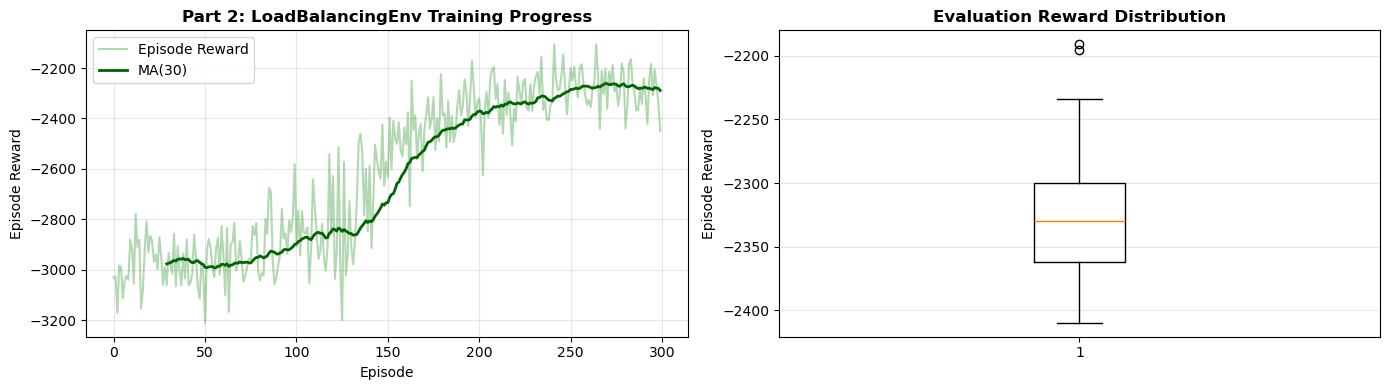

In [24]:
# ============================================================================
# Part 2 visualization
# ============================================================================
# Left plot: episode rewards + moving average
# Right plot: distribution of evaluation rewards

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: training trend
axes[0].plot(episode_rewards, alpha=0.3, label='Episode Reward', color='green')
ma_window = 30
ma_rewards = np.convolve(episode_rewards, np.ones(ma_window)/ma_window, mode='valid')
axes[0].plot(range(ma_window-1, len(episode_rewards)), ma_rewards, label=f'MA({ma_window})', color='darkgreen', linewidth=2)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Episode Reward')
axes[0].set_title('Part 2: LoadBalancingEnv Training Progress', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: evaluation spread
axes[1].boxplot(eval_rewards, vert=True)
axes[1].set_ylabel('Episode Reward')
axes[1].set_title('Evaluation Reward Distribution', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
plt.close(fig)  # Free figure memory

### 2.4: Comparing between DQN and Round Robin

In [ ]:
import csv
import time

def evaluate_and_save_csv(env, agent, filename="evaluation_results.csv", num_episodes=100):
    policies = ["DQN", "RoundRobin"]
    with open(filename, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([
            "Policy", "Episode", "TotalTime", "TasksCreated", "TasksAccepted",
            "TasksDropped", "TasksCompleted", "TotalReward", "AvgQueueTime",
            "LoadImbalance", "ServerFrequencies"
        ])

        for policy_name in policies:
            print(f"Running {policy_name}...")
            for ep in range(num_episodes):
                state, _ = env.reset()
                done = False
                start_time = time.time()
                total_reward = 0
                queue_history = []
                server_counts = [0] * env.num_servers
                rr_pointer = 0
                last_info = {"tasks_created":0, "tasks_accepted":0, "tasks_dropped":0, "tasks_completed":0}

                while not done:
                    if policy_name == "DQN":
                        action = agent.select_action(state, training=False)
                    else:
                        action = rr_pointer
                        rr_pointer = (rr_pointer + 1) % env.num_servers
                    
                    next_state, reward, term, trunc, info = env.step(action)
                    done = term or trunc
                    
                    server_counts[action] += 1
                    total_reward += reward
                    queue_history.append(sum(s.queue for s in env.servers))
                    state = next_state
                    if info: last_info = info 

                # 1. Tính toán tần suất chọn (Frequencies)
                total_steps = sum(server_counts)
                # Tính % cho mỗi server, ví dụ: [33.33, 33.33, 33.34]
                frequencies = [round((count / total_steps) * 100, 2) for count in server_counts]
                
                # 2. Tính toán các chỉ số khác
                end_time = time.time() - start_time
                avg_q = sum(queue_history)/len(queue_history) if queue_history else 0
                final_queues = [s.queue for s in env.servers]
                mean_q = sum(final_queues)/len(final_queues)
                imbalance = (sum((q - mean_q)**2 for q in final_queues)/len(final_queues))**0.5

                # 3. Ghi vào CSV
                writer.writerow([
                    policy_name, 
                    ep, 
                    f"{end_time:.4f}", 
                    last_info.get("tasks_created", 0), 
                    last_info.get("tasks_accepted", 0),
                    last_info.get("tasks_dropped", 0), 
                    last_info.get("tasks_completed", 0), 
                    f"{total_reward:.2f}", 
                    f"{avg_q:.2f}", 
                    f"{imbalance:.2f}", 
                    f"{frequencies}" # Lưu danh sách tần suất (%)
                ])
                
    print(f"✓ Hoàn thành! Dữ liệu đã lưu vào {filename}")

# Chạy hàm
evaluate_and_save_csv(env2, agent2)

Running DQN...
Running RoundRobin...
✓ Hoàn thành! Dữ liệu đã lưu vào evaluation_results.csv


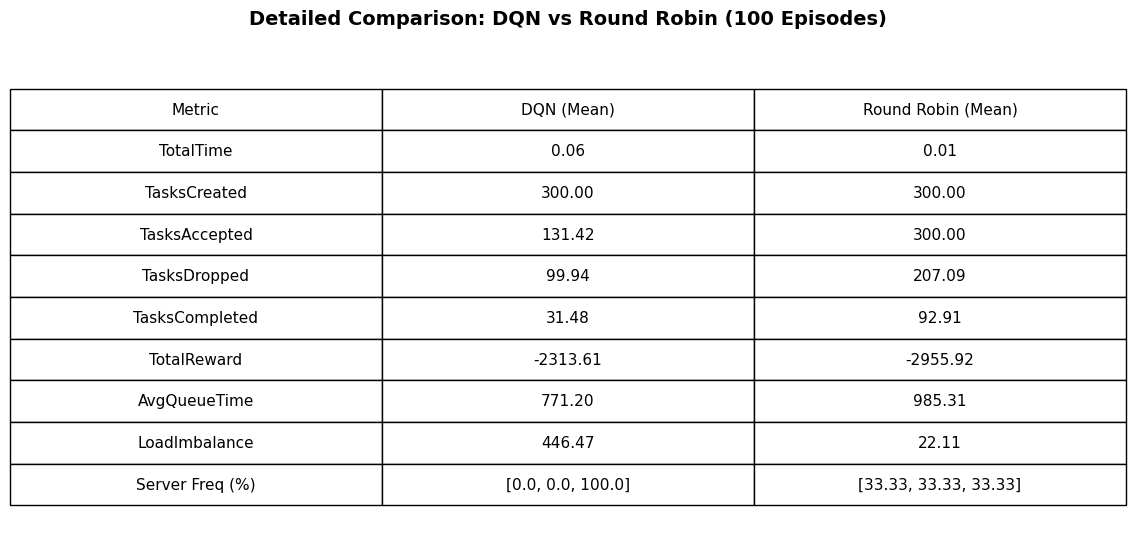

In [21]:
import ast # Thư viện an toàn để chuyển string thành list

def plot_comparison_table(filename="evaluation_results.csv"):
    # 1. Định nghĩa các metrics cần tính trung bình cộng
    metrics_to_avg = [
        "TotalTime", "TasksCreated", "TasksAccepted", 
        "TasksDropped", "TasksCompleted", "TotalReward", 
        "AvgQueueTime", "LoadImbalance"
    ]
    
    results = {"DQN": {}, "RoundRobin": {}}
    
    # Khởi tạo accumulator
    for p in results:
        for m in metrics_to_avg: 
            results[p][m] = 0.0
        results[p]["ServerFrequencies"] = None # Sẽ khởi tạo mảng sau
        results[p]["count"] = 0

    # 2. Đọc dữ liệu từ CSV
    with open(filename, mode='r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            p = row["Policy"]
            results[p]["count"] += 1
            
            # Cộng dồn các chỉ số số thực
            for m in metrics_to_avg:
                results[p][m] += float(row[m])
            
            # Xử lý đặc biệt cho ServerFrequencies (chuyển string "[...]" thành list)
            freq_list = ast.literal_eval(row["ServerFrequencies"])
            if results[p]["ServerFrequencies"] is None:
                results[p]["ServerFrequencies"] = [0.0] * len(freq_list)
            
            for i in range(len(freq_list)):
                results[p]["ServerFrequencies"][i] += freq_list[i]

    # 3. Chuẩn bị dữ liệu cho bảng
    table_data = []
    
    # Thêm các metrics thông thường
    for m in metrics_to_avg:
        dqn_val = results["DQN"][m] / results["DQN"]["count"]
        rr_val = results["RoundRobin"][m] / results["RoundRobin"]["count"]
        table_data.append([m, f"{dqn_val:.2f}", f"{rr_val:.2f}"])
    
    # Thêm dòng tần suất chọn Server (Trung bình)
    dqn_freq_avg = [round(x / results["DQN"]["count"], 2) for x in results["DQN"]["ServerFrequencies"]]
    rr_freq_avg = [round(x / results["RoundRobin"]["count"], 2) for x in results["RoundRobin"]["ServerFrequencies"]]
    table_data.append(["Server Freq (%)", str(dqn_freq_avg), str(rr_freq_avg)])

    # 4. Vẽ bảng bằng Matplotlib
    fig, ax = plt.subplots(figsize=(12, 6)) # Tăng kích thước để chứa thêm dòng
    ax.axis('off')
    
    headers = ["Metric", "DQN (Mean)", "Round Robin (Mean)"]
    table = ax.table(cellText=table_data, colLabels=headers, loc='center', cellLoc='center')
    
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 2.5) # Giãn dòng để dễ đọc
    
    plt.title("Detailed Comparison: DQN vs Round Robin (100 Episodes)", pad=30, fontweight='bold', fontsize=14)
    plt.show()

# Gọi hàm vẽ
plot_comparison_table()

### 2.5: New environment and DQN new trainning

In [65]:
# Lớp môi trường mới modify lại LoadBalancingEnv
class NewLB(gym.Env):
    def __init__(self, num_servers=3):
        super().__init__()
        self.num_servers = num_servers
        self.servers = [Server(speed=1.0) for _ in range(num_servers)]
        self.action_space = spaces.Discrete(num_servers)
        self.observation_space = spaces.Box(low=0, high=1, shape=(num_servers,), dtype=np.float32)
        
        self.max_steps = 300
        self.reset()

    def _get_state(self):
        return np.array([s.get_utilization() for s in self.servers], dtype=np.float32)

    def reset(self, seed=None):
        super().reset(seed=seed)
        self.servers = [Server(speed=1.0) for _ in range(self.num_servers)]
        self.steps = 0
        self.task_matrix = [[] for _ in range(self.num_servers)]
        self.tasks_created = 0
        self.tasks_completed = 0
        self.tasks_accepted = 0
        return self._get_state(), {}

    def step(self, action):
        self.steps += 1
        task_demand = np.random.randint(5, 15)
        self.tasks_created += 1
        
        # 1. Routing task (Giữ nguyên logic để thống kê)
        if len(self.task_matrix[action]) < 100:
            self.servers[action].add_task(task_demand)
            self.task_matrix[action].append(task_demand)
            self.tasks_accepted += 1

        # 2. Parallel Processing
        for i in range(self.num_servers):
            self.servers[i].process()
            speed_remaining = self.servers[i].speed
            while speed_remaining > 0 and len(self.task_matrix[i]) > 0:
                if self.task_matrix[i][0] <= speed_remaining:
                    speed_remaining -= self.task_matrix[i][0]
                    self.task_matrix[i].pop(0)
                    self.tasks_completed += 1
                else:
                    self.task_matrix[i][0] -= speed_remaining
                    speed_remaining = 0

        # --- REWARD TRIỆT TIÊU ĐỘ LỆCH ---
        queues = [s.queue for s in self.servers]
        imbalance = max(queues) - min(queues)

        # Phạt trực tiếp dựa trên độ lệch (Càng lệch càng đau)
        # Không dùng bình phương (vì nó làm số to quá AI khó học)
        # Dùng trị tuyệt đối nhưng hệ số cao
        r_imbalance = - (imbalance / 5.0) 

        # Thưởng thêm một chút nếu giữ được sự cân bằng hoàn hảo
        r_perfect = 5.0 if imbalance < 10 else 0.0

        reward = r_imbalance + r_perfect
        
        

        terminated = False
        truncated = self.steps >= self.max_steps
        info = {
            "tasks_created": self.tasks_created,
            "tasks_accepted": self.tasks_accepted,
            "tasks_completed": self.tasks_completed,
            "tasks_dropped": sum(len(q) for q in self.task_matrix) if truncated else 0
        }
        
        return self._get_state(), reward, terminated, truncated, info
print("Môi trường NewLB đã được tạo")

Môi trường NewLB đã được tạo


In [66]:
# ============================================================================
# New DQN training loop
# ============================================================================
print("\n" + "="*60)
print("Train new DQN ON NewLB")
print("="*60)

print("\n2.2: Training on NewLB")
print("-" * 60)

env2_new = NewLB(num_servers=3)
agent2_new = DQNAgent(state_size=3, action_size=3, learning_rate=1e-3)

# # Định nghĩa lại thông số cho Agent
# agent2_new.epsilon = 1.0
# agent2_new.epsilon_min = 0.02
# # Decay chậm hơn: 1.0 * (0.996^500) ≈ 0.13
# agent2_new.epsilon_decay = 0.997

num_episodes = 500
batch_size = 32

episode_rewards = []
episode_lengths = []

print(f"\nTraining for {num_episodes} episodes...\n")

for episode in range(num_episodes):
    state, _ = env2_new.reset()
    episode_reward = 0
    step_count = 0
    done = False

    while not done:
        # Instruction:
        # Complete the DQN interaction loop for LoadBalancingEnv.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        action = agent2_new.select_action(state)
        
        next_state, reward, terminated, truncated, _ = env2_new.step(action)
        done = terminated or truncated
        agent2_new.store_transition(state, action, reward, next_state, done)
        agent2_new.train_step(batch_size)
        episode_reward += reward
        step_count += 1
        state = next_state

    # Chỉ thực hiện decay sau mỗi Episode
    agent2_new.decay_epsilon()
    episode_rewards.append(episode_reward)
    episode_lengths.append(step_count)

    if (episode + 1) % 50 == 0:
        avg_reward = np.mean(episode_rewards[-50:])
        print(f"Episode {episode+1:3d}/{num_episodes} | Avg Reward (last 50): {avg_reward:.2f} | Epsilon: {agent2_new.epsilon:.3f}")

print(f"\nTraining completed!")
print(f"Final average reward (last 50 episodes): {np.mean(episode_rewards[-50:]):.2f}")



Train new DQN ON NewLB

2.2: Training on NewLB
------------------------------------------------------------

Training for 500 episodes...

Episode  50/500 | Avg Reward (last 50): -7640.19 | Epsilon: 0.778
Episode 100/500 | Avg Reward (last 50): -16074.05 | Epsilon: 0.606
Episode 150/500 | Avg Reward (last 50): -27343.51 | Epsilon: 0.471
Episode 200/500 | Avg Reward (last 50): -38916.38 | Epsilon: 0.367
Episode 250/500 | Avg Reward (last 50): -41708.42 | Epsilon: 0.286
Episode 300/500 | Avg Reward (last 50): -43174.54 | Epsilon: 0.222
Episode 350/500 | Avg Reward (last 50): -44397.18 | Epsilon: 0.173
Episode 400/500 | Avg Reward (last 50): -43731.20 | Epsilon: 0.135
Episode 450/500 | Avg Reward (last 50): -45041.62 | Epsilon: 0.105
Episode 500/500 | Avg Reward (last 50): -45720.43 | Epsilon: 0.082

Training completed!
Final average reward (last 50 episodes): -45720.43


In [67]:
import csv
import time
# Hàm so sánh DQN cũ, DQN mới, Round Robin trên LoadBalancingEnv chưa modify
def evaluate_three_policies(env, agent_old, agent_new, filename="final_comparison.csv", num_episodes=100):
    # Danh sách các chính sách: (Tên, Đối tượng Agent hoặc None cho RR)
    policies = [
        ("DQN_Old", agent_old), 
        ("DQN_New", agent_new), 
        ("RoundRobin", None)
    ]
    
    with open(filename, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([
            "Policy", "Episode", "TotalTime", "TasksCreated", "TasksAccepted",
            "TasksDropped", "TasksCompleted", "TotalReward", "AvgQueueTime",
            "LoadImbalance", "ServerFrequencies"
        ])

        for name, agent in policies:
            print(f"Evaluating {name}...")
            for ep in range(num_episodes):
                state, _ = env.reset()
                done = False
                start_time = time.time()
                total_reward = 0
                queue_history = []
                server_counts = [0] * env.num_servers
                rr_pointer = 0
                last_info = {}

                while not done:
                    if name == "RoundRobin":
                        action = rr_pointer
                        rr_pointer = (rr_pointer + 1) % env.num_servers
                    else:
                        # Cả agent_old và agent_new đều dùng select_action
                        action = agent.select_action(state, training=False)
                    
                    next_state, reward, term, trunc, info = env.step(action)
                    done = term or trunc
                    server_counts[action] += 1
                    total_reward += reward
                    queue_history.append(sum(s.queue for s in env.servers))
                    state = next_state
                    last_info = info

                # Tính toán thống kê
                end_time = time.time() - start_time
                avg_q = np.mean(queue_history) if queue_history else 0
                final_queues = [s.queue for s in env.servers]
                mean_q = np.mean(final_queues)
                imbalance = np.std(final_queues) # Độ lệch chuẩn
                total_steps = sum(server_counts)
                freqs = [round((c/total_steps)*100, 2) for c in server_counts]

                writer.writerow([
                    name, ep, f"{end_time:.4f}", 
                    last_info.get("tasks_created", 0), 
                    last_info.get("tasks_accepted", 0),
                    last_info.get("tasks_dropped", 0), 
                    last_info.get("tasks_completed", 0), 
                    f"{total_reward:.2f}", f"{avg_q:.2f}", f"{imbalance:.2f}", str(freqs)
                ])
                
    print(f"✓ Evaluation finished. Data saved to {filename}")

# THỰC THI: Chạy trên env2 (Môi trường cũ)
evaluate_three_policies(env2, agent2, agent2_new)

Evaluating DQN_Old...
Evaluating DQN_New...
Evaluating RoundRobin...
✓ Evaluation finished. Data saved to final_comparison.csv


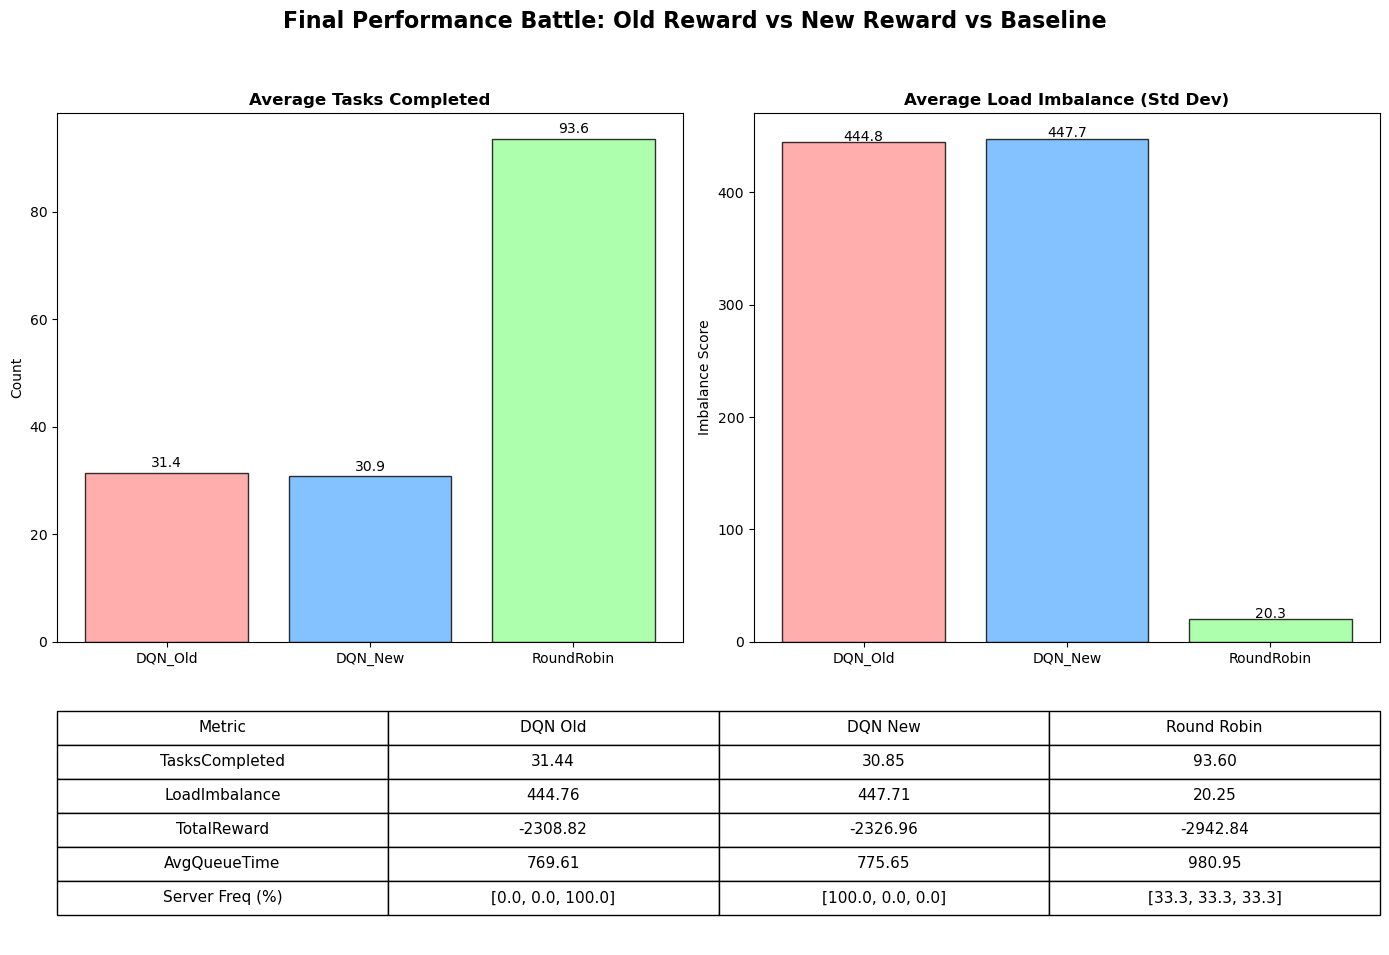

In [68]:
import csv
import matplotlib.pyplot as plt
import ast
import numpy as np

def plot_final_comparison(filename="final_comparison.csv"):
    # 1. Khởi tạo cấu trúc dữ liệu để gom nhóm
    # Các chỉ số cần tính trung bình
    metrics = ["TasksCompleted", "LoadImbalance", "TotalReward", "AvgQueueTime"]
    policies = ["DQN_Old", "DQN_New", "RoundRobin"]
    
    # dict để lưu: data[policy][metric] = [list các giá trị]
    data_store = {p: {m: [] for m in metrics} for p in policies}
    freq_store = {p: [] for p in policies}

    # 2. Đọc file CSV bằng module csv chuẩn
    with open(filename, mode='r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            p = row["Policy"]
            if p in data_store:
                for m in metrics:
                    data_store[p][m].append(float(row[m]))
                # Xử lý chuỗi list tần suất
                freq_list = ast.literal_eval(row["ServerFrequencies"])
                freq_store[p].append(freq_list)

    # 3. Tính toán giá trị trung bình (Mean)
    means = {p: {m: np.mean(data_store[p][m]) for m in metrics} for p in policies}
    avg_freqs = {p: np.mean(freq_store[p], axis=0) for p in policies}

    # 4. Chuẩn bị dữ liệu cho Bảng
    # Hàng: Các Metric, Cột: Các Policy
    table_text = []
    for m in metrics:
        row_data = [m]
        for p in policies:
            row_data.append(f"{means[p][m]:.2f}")
        table_text.append(row_data)
    
    # Thêm hàng Tần suất chọn Server vào bảng
    freq_row = ["Server Freq (%)"]
    for p in policies:
        formatted_freq = [round(float(x), 1) for x in avg_freqs[p]]
        freq_row.append(str(formatted_freq))
    table_text.append(freq_row)

    # 5. Khởi tạo Figure với GridSpec (1 hàng cho biểu đồ, 1 hàng cho bảng)
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 0.5])
    
    # --- BIỂU ĐỒ 1: Tasks Completed (Càng cao càng tốt) ---
    ax1 = fig.add_subplot(gs[0, 0])
    vals1 = [means[p]["TasksCompleted"] for p in policies]
    colors = ['#ff9999','#66b3ff','#99ff99']
    ax1.bar(policies, vals1, color=colors, edgecolor='black', alpha=0.8)
    ax1.set_title("Average Tasks Completed", fontweight='bold')
    ax1.set_ylabel("Count")
    for i, v in enumerate(vals1):
        ax1.text(i, v + 1, f"{v:.1f}", ha='center')

    # --- BIỂU ĐỒ 2: Load Imbalance (Càng thấp càng tốt) ---
    ax2 = fig.add_subplot(gs[0, 1])
    vals2 = [means[p]["LoadImbalance"] for p in policies]
    ax2.bar(policies, vals2, color=colors, edgecolor='black', alpha=0.8)
    ax2.set_title("Average Load Imbalance (Std Dev)", fontweight='bold')
    ax2.set_ylabel("Imbalance Score")
    for i, v in enumerate(vals2):
        ax2.text(i, v + 1, f"{v:.1f}", ha='center')

    # --- BẢNG CHI TIẾT ---
    ax_table = fig.add_subplot(gs[1, :])
    ax_table.axis('off')
    col_labels = ["Metric", "DQN Old", "DQN New", "Round Robin"]
    
    the_table = ax_table.table(
        cellText=table_text, 
        colLabels=col_labels, 
        loc='center', 
        cellLoc='center'
    )
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(11)
    the_table.scale(1, 1.8)

    plt.suptitle("Final Performance Battle: Old Reward vs New Reward vs Baseline", fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Gọi hàm
plot_final_comparison()

---

# PART 3: DQN with Stable-Baselines3

Production-ready implementation using the Stable-Baselines3 library. This is more efficient and less error-prone than manual implementation.

### 3.1: Import Stable-Baselines3

In [ ]:
# ============================================================================
# Part 3 setup for SB3
# ============================================================================
# We keep this implementation simple and use FrozenLake-v1 (as in Lab 3.1).

print("\n" + "="*60)
print("PART 3: STABLE-BASELINES3 DQN ON FROZENLAKE-V1")
print("="*60)

print("\n3.1: Import Stable-Baselines3")
print("-" * 60)

try:
    from stable_baselines3 import DQN
    sb3_available = True
    print("✓ Stable-Baselines3 imported successfully")
except Exception as e:
    sb3_available = False
    print("⚠ SB3 import failed in this environment")
    print(f"  Error: {type(e).__name__}: {e}")
    print("  Please check package compatibility in env nt549-1-phatpt.")

### 3.2: Train SB3 DQN on FrozenLake-v1 (Simple)

In [ ]:
# ============================================================================
# Part 3 train/eval with SB3 on FrozenLake-v1
# ============================================================================

if sb3_available:
    print("\n3.2: Training SB3 DQN on FrozenLake-v1")
    print("-" * 60)

    ### YOU NEED TO WRITE YOUR CODE BELOW ###
    # 1) Create FrozenLake-v1 environment
    # 2) Initialize SB3 DQN model
    # 3) Train model with suitable timesteps
    env_sb3 = gym.make('FrozenLake-v1', map_name='4x4', is_slippery=False)

    model = DQN(
        policy='MlpPolicy',
        env=env_sb3,
        learning_rate=1e-3,
        buffer_size=5000,
        learning_starts=200,
        batch_size=32,
        gamma=0.99,
        train_freq=4,
        target_update_interval=250,
        verbose=0
    )

    total_timesteps = 10000
    print(f"Training for {total_timesteps} timesteps...\n")
    model.learn(total_timesteps=total_timesteps)
    print("Training completed!\n")

    print("3.3: Evaluation of SB3 DQN on FrozenLake-v1")
    print("-" * 60)

    eval_episodes = 30
    sb3_eval_rewards = []

    for _ in range(eval_episodes):
        obs, _ = env_sb3.reset()
        done = False
        episode_reward = 0.0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            if isinstance(action, np.ndarray):
                action = int(action.item())
            obs, reward, terminated, truncated, _ = env_sb3.step(action)
            done = terminated or truncated
            episode_reward += reward

        sb3_eval_rewards.append(episode_reward)

    success_rate = sum(1 for r in sb3_eval_rewards if r > 0) / eval_episodes * 100
    print("SB3 Evaluation Results:")
    print(f"  Average Reward: {np.mean(sb3_eval_rewards):.2f}")
    print(f"  Success Rate: {success_rate:.1f}%")
    print(f"  Min Reward: {np.min(sb3_eval_rewards):.2f}")
    print(f"  Max Reward: {np.max(sb3_eval_rewards):.2f}")

    env_sb3.close()
else:
    print("\n⚠ Skipping SB3 training because SB3 import was not successful.")


### 3.4: Key Advantages of Stable-Baselines3

Summary of benefits of using production-ready RL libraries.

In [ ]:
# ============================================================================
# Part 3 concept summary
# ============================================================================
# Keep this as a teaching recap slide in code form (easy to run/print).

print("\n3.4: Key Advantages of Stable-Baselines3")
print("="*60)

print("""
1. Optimized Implementation:
   - Highly optimized algorithms (better than manual implementation)
   - Less error-prone (extensively tested)
   - Better hyperparameter tuning utilities

2. Features:
   - Built-in support for multiple algorithms
   - Vectorized environment support
   - Automatic GPU acceleration
   - Callbacks and monitoring

3. Production Ready:
   - Used in industry and research
   - Active community and support
   - Benchmarked and validated

4. When to Use:
   - Quick prototyping: Use SB3
   - Learning fundamentals: Use manual implementation
   - Production systems: Use SB3
   - Custom algorithms: Use PyTorch/TensorFlow directly
""")

print("="*60)

---

# PART 4: Student Exercise - SB3 DQN on VacuumCleanerEnv

In this part, you will implement SB3 DQN directly on `VacuumCleanerEnv`.
Focus on:
1. environment setup
2. model configuration
3. training
4. evaluation and comparison with Part 1 manual DQN


### 4.1: Implement SB3 DQN for VacuumCleanerEnv

Follow the comments carefully and complete all TODO blocks.


In [ ]:
print("\n" + "="*60)
print("PART 4: SB3 DQN ON VACUUMCLEANERENV")
print("="*60)

# Step 1: Create environment
### YOU NEED TO WRITE YOUR CODE BELOW ###
env_sb3_vacuum = None

# Step 2: Build SB3 DQN model
# Suggested parameters to try:
# - learning_rate: 1e-3 or 5e-4
# - buffer_size: 10000 or 20000
# - batch_size: 32 or 64
### YOU NEED TO WRITE YOUR CODE BELOW ###
model_sb3_vacuum = None

# Step 3: Train
### YOU NEED TO WRITE YOUR CODE BELOW ###
total_timesteps = 50000
# model_sb3_vacuum.learn(total_timesteps=total_timesteps)

print("Training finished (if implemented).")


### 4.2: Evaluate SB3 on VacuumCleanerEnv

Compute average reward, clean ratio, and completion rate over multiple episodes.


In [ ]:
# Evaluation template
### YOU NEED TO WRITE YOUR CODE BELOW ###
# Suggested structure:
# eval_episodes = 30
# rewards = []
# clean_ratios = []
# completions = []
# for _ in range(eval_episodes):
# 
#     # collect metrics from environment

print("Please complete evaluation code for Part 4.")


---

## Summary and Key Takeaways

## CONGRATULATIONS TEAM!

Congratulations on completing Lab 03.2 - Introduction to Deep Q-Network!

You have successfully:
- Designed and implemented custom Gymnasium environments (VacuumCleanerEnv, LoadBalancingEnv)
- Trained DQN agents on multiple custom environments
- Learned how to use Stable-Baselines3 for production-ready RL
- Compared manual vs. library-based implementations
- Evaluated agents and visualized training progress

You now have the skills to apply DQN to real-world problems!

References: https://gymnasium.farama.org/ | https://stable-baselines3.readthedocs.io/

## ADDITIONAL INFORMATION

**Author**: M.Sc. Phan Trung Phat - Department of Computer Networks and Communications, UIT

**Contact**: phatpt@uit.edu.vn

**Last Updated**: March, 2026